In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy import stats
from iminuit import Minuit, cost

from matplotlib.markers import MarkerStyle

my_cmap = plt.colormaps["rainbow"]
my_marker=MarkerStyle(marker="1", fillstyle='full', transform=None, capstyle=None, joinstyle=None)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['savefig.dpi']=600
plt.rcParams["savefig.bbox"]='tight'
plt.rcParams["figure.figsize"]='5,3'
text_style = dict(horizontalalignment='right', verticalalignment='center',
                  fontsize=12, fontfamily='monospace')

r = np.random
r.seed(42)

In [3]:
def fct(x,a,b):

    y=1+a*x+b*x**2
    return y


def fit_func_normalized(x,a,b) :
    #integral=scipy.integrate.quad(lambda x: fct(x,a,b), x_min, x_max)[0]
    integral= (2 * (1 + b / 3))
    y=fct(x,a,b)/integral
    return y


def neg_ln_likelihood(array,a,b):
    llh=0
    for x in array:
        llh=-np.log(fit_func_normalized(x,a, b))+llh
    return llh




def sample_data_via_accept_reject(xmin:float=0, xmax:float=1, N_samples:int=10000, a:float=0.0, b:float=0.0)->np.array:
    """data generated with accept/reject method for given function within given boundaries, returns array of accepted x values"""

    #sample_func=samp_func
    x_accepted = np.zeros(N_samples)

    list_x = np.linspace(xmin, xmax, 1000)
    list_y = fit_func_normalized(list_x,a,b)
    ymax = np.max(list_y)*1.1
    #print(f'Maximum of function: {ymax}')

    for i in range(N_samples):
        while True:
            x_rand = r.uniform(xmin, xmax)  
            y_rand = r.uniform(0, ymax)            
            if (y_rand < fit_func_normalized(x_rand,a,b)):
                break
                
        x_accepted[i] = x_rand
    return x_accepted

(np.float64(-0.9998),
 np.float64(0.9986),
 np.float64(-0.9978),
 np.float64(0.9998))

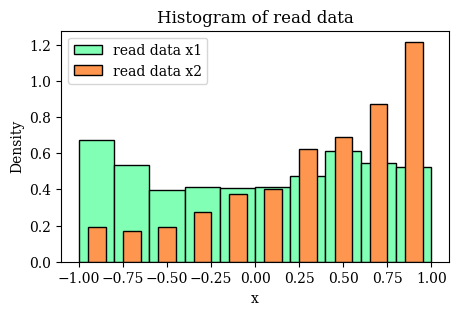

In [28]:
df = pd.read_csv('MLE_Variance_data.txt',header=None,sep=" ")
x1_array=df[0].values
x2_array=df[1].values

x1_min = x1_array.min()
x1_max = x1_array.max()

x2_min = x2_array.min()
x2_max = x2_array.max()


fig,ax=plt.subplots(1)
ax.hist(x1_array, bins=10, density=True,color=my_cmap(0.5), edgecolor='black',rwidth=1,label="read data x1")
ax.hist(x2_array, bins=10, density=True,color=my_cmap(0.8), edgecolor='black',rwidth=0.5,label="read data x2")
ax.legend()
ax.set_xlabel("x")
ax.set_ylabel("Density")
ax.set_title("Histogram of read data")

x1_min, x1_max, x2_min, x2_max



## Fitting a and b


In [11]:
#generate raster data of likelihood and llh
n_a=20
n_b=20
a_min=0
a_max=1
b_min=0
b_max=1


raster_array_llh=np.zeros([n_a,n_b])

for i_a,a in enumerate(np.linspace(a_min, a_max, n_a)):
    for i_b,b in enumerate(np.linspace(b_min, b_max, n_b)):
        llh=neg_ln_likelihood(df["x"],a,b)
        raster_array_llh[i_a,i_b]=llh

/tmp/ipykernel_5612/3286230244.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_raster.legend()


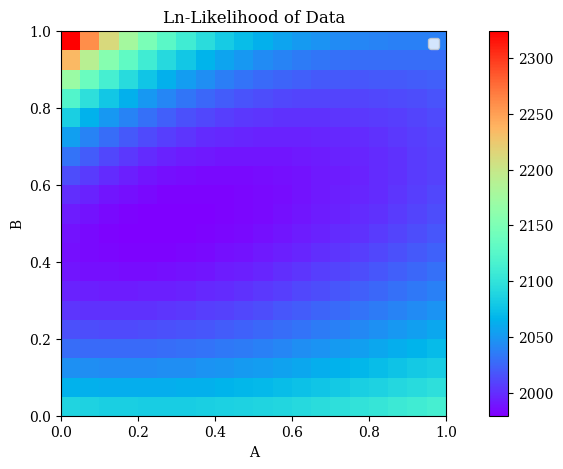

In [ ]:
#draw raster plot
fig_raster, ax_raster = plt.subplots(1,figsize=(11, 5))
im_raster=ax_raster.imshow(raster_array_llh, cmap=my_cmap,  aspect=None, extent=(a_min, a_max,b_min, b_max), origin='lower')
ax_raster.set_ylabel('B')
ax_raster.set_xlabel('A')
ax_raster.set_title('Ln-Likelihood of Data')
ax_raster.legend()


cbar_raster = ax_raster.figure.colorbar(im_raster, ax=ax_raster)#, **cbar_kw)

In [13]:
#define starting values for fit parameters a and b, and perform fit using Minuit

mfit = Minuit(lambda a,b: neg_ln_likelihood(df["x"], a,b), a=a_min, b=b_min)
    
mfit.migrad()

a_fit, b_fit = mfit.values["a"], mfit.values["b"]
print(f"Best fit parameters: a={a_fit:.3f}, b={b_fit:.3f}")

Best fit parameters: a=0.504, b=0.275


## 2b finding out the uncertainty by bootstrapping method

In [14]:
"""generating pseudo data with accept/reject method for given function within given boundaries"""
x_min=-1
x_max=1

pseudo_array=[]
pseudo_array_a_fit=[]
pseudo_array_b_fit=[]

for i in range(50):
    data=sample_data_via_accept_reject(xmin=x_min, xmax=x_max, N_samples=3013, a=a_fit, b=b_fit)
    pseudo_array.append(data);
    mfit_pseudo = Minuit(lambda a,b: neg_ln_likelihood(data, a,b), a=a_min, b=b_min)
    #setting bounds for fit parameters a and b, and perform fit using Minuit
    mfit_pseudo.limits["a"] = (a_min, a_max)
    mfit_pseudo.limits["b"] = (b_min,b_max)
    mfit_pseudo.migrad()
    pseudo_array_a_fit.append(mfit_pseudo.values["a"])
    pseudo_array_b_fit.append(mfit_pseudo.values["b"])


Text(0.5, 1.0, 'Scatter plot of fitted a vs b values from pseudo data')

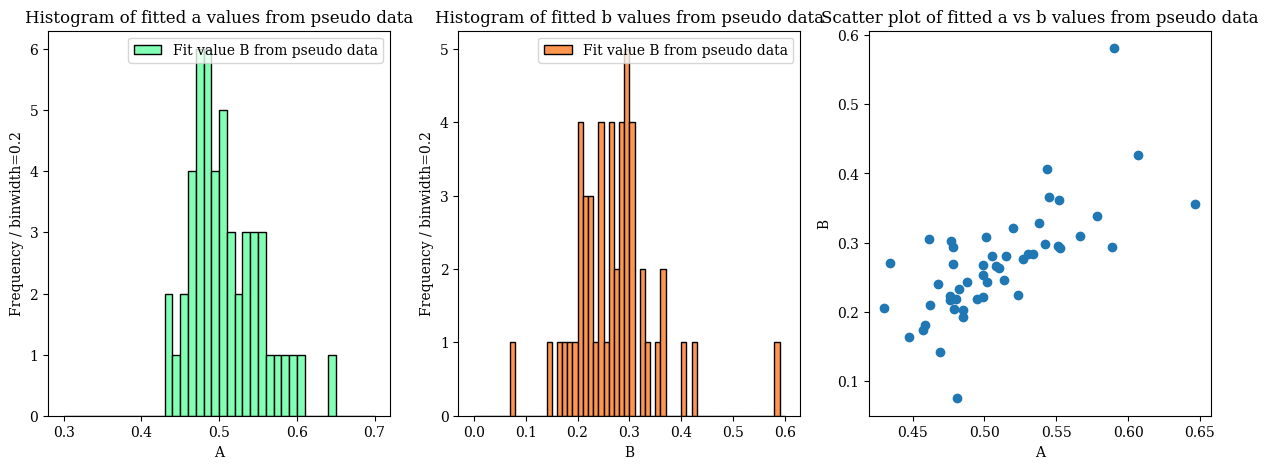

In [26]:
fig,ax=plt.subplots(1,3,figsize=(15, 5))
counts_a,bins_a,_=ax[0].hist(pseudo_array_a_fit, bins=40,range=(0.3, 0.7), color=my_cmap(0.5), edgecolor='black',rwidth=1,label="Fit value B from pseudo data")
ax[0].set_ylabel(f'Frequency / binwidth={2/10}')
ax[0].set_xlabel('A')
ax[0].set_title('Histogram of fitted a values from pseudo data')
ax[0].legend()


counts_b,bins_b,_=ax[1].hist(pseudo_array_b_fit, bins=60, range=(0, 0.6), color=my_cmap(0.8), edgecolor='black',rwidth=1,label="Fit value B from pseudo data")
ax[1].set_ylabel(f'Frequency / binwidth={2/10}')
ax[1].set_xlabel('B')
ax[1].set_title('Histogram of fitted b values from pseudo data')
ax[1].legend()


ax[2].scatter(pseudo_array_a_fit,pseudo_array_b_fit)
ax[2].set_xlabel('A')
ax[2].set_ylabel('B')
ax[2].set_title('Scatter plot of fitted a vs b values from pseudo data')


## #2c

In [ ]:
"""using the raster array to estimate the uncertainty of the fit parameters a and b, by finding the contour levels corresponding to 1-sigma confidence intervals"""



68% confidence interval for a: (np.float64(0.45999999999999996), np.float64(0.5499999999999999))
68% confidence interval for b: (np.float64(0.2), np.float64(0.32))
